<a href="https://colab.research.google.com/github/Ravindu-Pathirana/Deep_Neural_Network_Tutorial/blob/main/Regression_DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import opendatasets as od

In [4]:
od.download("https://www.kaggle.com/datasets/andonians/random-linear-regression")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: uom230467r
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andonians/random-linear-regression


100%|██████████| 7.63k/7.63k [00:00<00:00, 8.66MB/s]

In [5]:
data = pd.read_csv("/content/random-linear-regression/test.csv")

In [6]:
data.head()

,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864


In [7]:
data.shape

(300, 2)

In [8]:
x = data.drop("y", axis=1)
y = data["y"]

In [9]:
x

,x
0,77
1,21
2,22
3,20
4,36
...,...
295,71
296,46
297,55
298,62


In [10]:
y

,y
0,79.775152
1,23.177279
2,25.609262
3,17.857388
4,41.849864
...,...
295,68.545888
296,47.334876
297,54.090637
298,63.297171


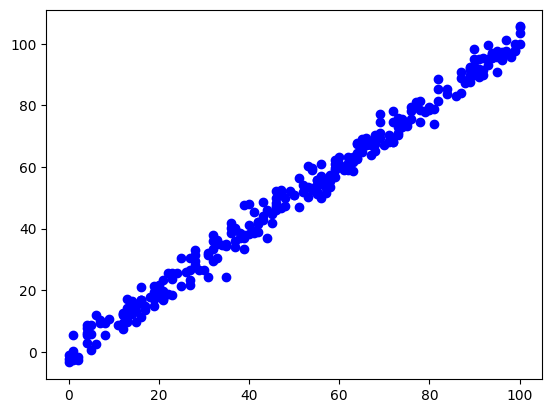

In [11]:
plt.scatter(x, y, c='b')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [15]:
x_train.shape, x_test.shape

((240, 1), (60, 1))

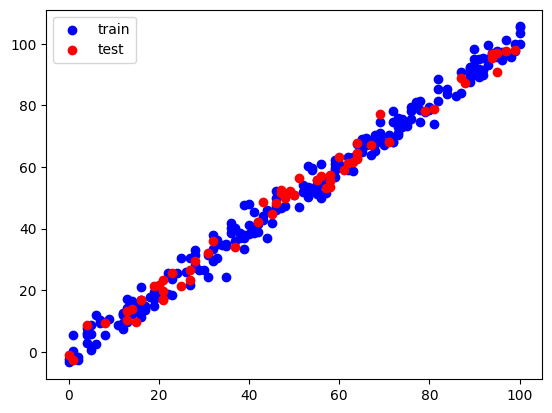

In [16]:
plt.scatter(x_train, y_train, c='b', label='train')
plt.scatter(x_test, y_test, c='r', label='test')
plt.legend()
plt.show()

#Model Building

In [73]:
#create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, input_shape=[1], ),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

#compile model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01),
              metrics=['mae'])
#Train model
history = model.fit(tf.expand_dims(x_train,axis=1), y_train, epochs =4 )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 8.4681 - mae: 8.4681  
Epoch 2/4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9751 - mae: 2.9751
Epoch 3/4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.8518 - mae: 2.8518 
Epoch 4/4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.0427 - mae: 3.0427 


In [65]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,369 (9.26 KB)

 Trainable params: 789 (3.08 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,580 (6.18 KB)

In [66]:
y_pred = model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


In [67]:
y_pred[:5]

array([[49.019505],
       [62.738693],
       [26.480827],
       [55.879097],
       [56.85904 ]], dtype=float32)

In [68]:
y_test[:5]

,y
67,50.963436
57,62.600898
81,23.444792
199,53.116284
176,57.487414


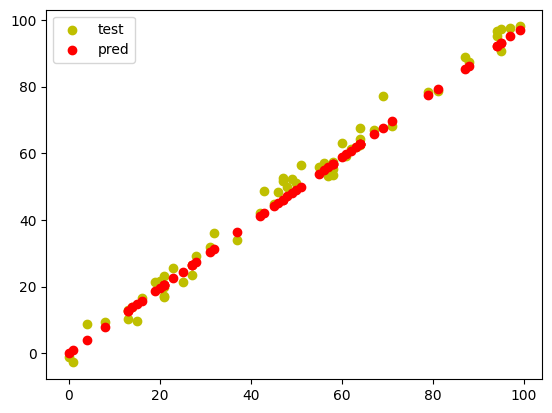

In [69]:
plt.scatter(x_test, y_test, c='y', label='test')
plt.scatter(x_test, y_pred, c='r', label='pred')
plt.legend()
plt.show()

In [70]:
model.evaluate(x_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.5753 - mae: 2.5753 


[2.5752828121185303, 2.5752828121185303]

In [71]:
# Using MAE (mean absolute error)
mae = tf.metrics.mae(y_test, tf.squeeze(y_pred)) # all are required to be one dimensional
mae

<tf.Tensor: shape=(), dtype=float32, numpy=2.5752830505371094>

In [35]:
y_pred.shape

(60, 1)

In [36]:
y_test.shape

(60,)

In [38]:
tf.squeeze(y_pred).shape

TensorShape([60])

In [72]:
mse = tf.metrics.mse(y_test, tf.squeeze(y_pred)) # all are required to be one dimensional
mse

<tf.Tensor: shape=(), dtype=float32, numpy=10.378049850463867>

In [74]:
history.history

{'loss': [8.468149185180664,
  2.975114583969116,
  2.8517560958862305,
  3.042678117752075],
 'mae': [8.468149185180664,
  2.975114583969116,
  2.8517560958862305,
  3.042678117752075]}

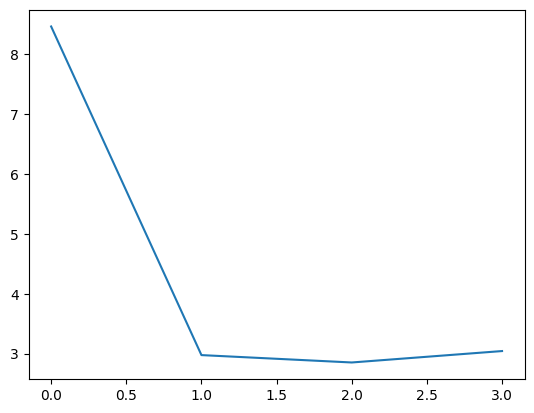

In [89]:
x_range = range(len(history.history['loss']))
plt.plot(x_range, history.history['loss'])
plt.show()

In [96]:
for layer in model.layers:
  weights = layer.get_weights()[0]
  biases = layer.get_weights()[1]
  print(f'weights :{weights}')
  print(f'biases :{biases}')

weights :[[-0.11768297  0.26295248 -0.21978644 -0.24631268 -0.25721624  0.13123928
   0.1608962  -0.11882149  0.17176554  0.17419408 -0.2766968   0.08401784
   0.06284223 -0.03101332 -0.24272002  0.03435681  0.18282467  0.1515108
   0.27134466  0.13075401  0.24847361  0.19712189 -0.23150645  0.22452018
   0.16061372 -0.00337611 -0.2650895  -0.3025515   0.24330841 -0.03607751
   0.18791606 -0.1090471   0.26416472 -0.17441162 -0.28141436  0.00918359
   0.28966334 -0.07094176 -0.27377343 -0.20916192 -0.19076319 -0.17926238
  -0.01261442 -0.06125353 -0.10152557 -0.15685304  0.10875239  0.07690278
  -0.14379926 -0.05169924 -0.23379722  0.07157391  0.09711621 -0.10423379
  -0.18463388  0.23175618  0.13935584  0.02069203  0.1611565  -0.23713838
   0.22291437  0.18731502 -0.26239935  0.1755735 ]]
biases :[ 0.06103934 -0.01891356  0.09248935  0.00747465  0.0105703  -0.01836458
 -0.02120099 -0.00444775 -0.01838649 -0.01933922  0.01542276 -0.01454089
 -0.00316403  0.02689683  0.01880898 -0.019802